# ラフネス（Roughness）— 協和・不協和の定量解析

ラフネスは音の「ざらつき感」を定量化する知覚指標。2つの音の差音が 20〜300 Hz の範囲にあると、聴覚系で変調（ビート）が生じ、不協和感として知覚される。

## このノートブックで学ぶこと

1. ラフネスの理論（Sethares モデル）と計算方法
2. 差音とラフネス曲線の関係
3. 音楽的音程ごとのラフネス比較（協和・不協和の客観評価）
4. Karplus-Strong の和音のラフネス
5. FM 合成の C:M 比とラフネスの関係

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import soundfile as sf
from pathlib import Path
from scipy.signal import find_peaks
from scipy.fft import rfft, rfftfreq

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

SR = 44100
DATA_DIR = Path('../data/roughness')
DATA_DIR.mkdir(parents=True, exist_ok=True)
print('準備完了')

準備完了


---
## 1. Sethares モデルの実装

Sethares（1993）のモデルは、倍音ペアの振幅と周波数差から粗さを算出する。

```
Roughness = Σ_{i<j} A_i · A_j · g(f_i, f_j)

g(f_i, f_j) = max(0, e^(-a·x) - e^(-b·x))
  ただし x = |f_i - f_j| / (0.021·min(f_i,f_j) + 19)
  a = 3.5, b = 5.75
```

`x` は臨界帯域幅（Bark スケール）に正規化された差音。`x ≈ 0.24` 付近で粗さが最大になる。

In [2]:
def roughness_sethares(freqs: np.ndarray, amps: np.ndarray) -> float:
    """
    Sethares (1993) のラフネスモデル。
    freqs : 各部分音の周波数 [Hz]
    amps  : 各部分音の正規化振幅 (0〜1)
    """
    a, b = 3.5, 5.75
    roughness = 0.0
    n = len(freqs)
    for i in range(n):
        for j in range(i + 1, n):
            fmin = min(freqs[i], freqs[j])
            df   = abs(freqs[j] - freqs[i])
            x    = df / (0.021 * fmin + 19)
            r    = amps[i] * amps[j] * (np.exp(-a * x) - np.exp(-b * x))
            roughness += max(0.0, r)
    return roughness


def spectrum_to_partials(signal, sr, n_harmonics=16):
    """FFT から主要な部分音（周波数・振幅）を抽出する"""
    N = len(signal)
    spec = np.abs(rfft(signal * np.hanning(N)))
    fq   = rfftfreq(N, 1 / sr)
    min_dist = int(20 / (sr / N))   # 20 Hz 以上の間隔のピークを検出
    peaks, _ = find_peaks(spec, distance=max(2, min_dist),
                           height=spec.max() * 0.005)
    # 上位 n_harmonics 個に絞る
    top = sorted(peaks, key=lambda p: spec[p], reverse=True)[:n_harmonics]
    f = fq[top]
    a = spec[top] / spec.max()
    return f, a


print('ラフネス関数を定義しました')

ラフネス関数を定義しました


---
## 2. ラフネス曲線 — 差音とラフネスの関係

基音 A4（440 Hz）の純音と、それより高い純音の差音を 0〜600 Hz まで変化させ、ラフネスを計算する。  
差音 ≈ 30〜80 Hz 付近でラフネスが最大になることを確認する。

/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_88971/3932028394.py:29: UserWarning: Glyph 24046 (\N{CJK UNIFIED IDEOGRAPH-5DEE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_88971/3932028394.py:29: UserWarning: Glyph 38899 (\N{CJK UNIFIED IDEOGRAPH-97F3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_88971/3932028394.py:29: UserWarning: Glyph 12521 (\N{KATAKANA LETTER RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_88971/3932028394.py:29: UserWarning: Glyph 12501 (\N{KATAKANA LETTER HU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_88971/3932028394.py:29: UserWarning: Glyph 12493 (\N{KATAKANA LETTER NE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000

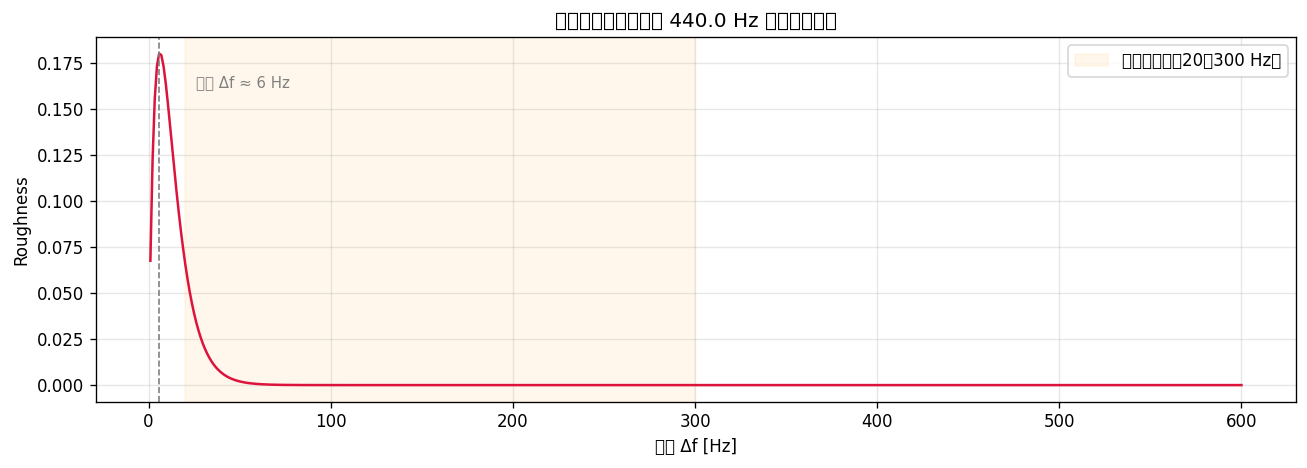

ラフネス最大点: Δf = 5.8 Hz


In [3]:
f_base = 440.0
delta_f_range = np.linspace(1, 600, 500)
roughness_curve = [
    roughness_sethares(
        np.array([f_base, f_base + df]),
        np.array([1.0, 1.0])
    )
    for df in delta_f_range
]
roughness_curve = np.array(roughness_curve)

# 最大点
peak_idx = np.argmax(roughness_curve)
peak_df  = delta_f_range[peak_idx]

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(delta_f_range, roughness_curve, color='crimson', linewidth=1.5)
ax.axvline(peak_df, color='gray', linestyle='--', linewidth=1)
ax.annotate(f'最大 Δf ≈ {peak_df:.0f} Hz',
            xy=(peak_df, roughness_curve[peak_idx]),
            xytext=(peak_df + 20, roughness_curve[peak_idx] * 0.9),
            fontsize=9, color='gray')
# 不快な差音帯域（20〜300 Hz）を塗りつぶす
ax.axvspan(20, 300, alpha=0.08, color='orange', label='不協和帯域（20〜300 Hz）')
ax.set_xlabel('差音 Δf [Hz]')
ax.set_ylabel('Roughness')
ax.set_title(f'ラフネス曲線（基音 {f_base} Hz の純音ペア）')
ax.legend()
plt.tight_layout()
plt.savefig(DATA_DIR / 'roughness_curve.png', bbox_inches='tight')
plt.show()
print(f'ラフネス最大点: Δf = {peak_df:.1f} Hz')

---
## 3. 音楽的音程のラフネス比較

基音 A4（440 Hz）と各音程のラフネスを比較する。倍音を含む現実的な音（Karplus-Strong）で計算する。  
西洋音楽の協和音程が低ラフネスを示すか確認する。

/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_88971/2711039425.py:60: UserWarning: Glyph 12518 (\N{KATAKANA LETTER YU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_88971/2711039425.py:60: UserWarning: Glyph 12491 (\N{KATAKANA LETTER NI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_88971/2711039425.py:60: UserWarning: Glyph 12478 (\N{KATAKANA LETTER ZO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_88971/2711039425.py:60: UserWarning: Glyph 12531 (\N{KATAKANA LETTER N}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_88971/2711039425.py:60: UserWarning: Glyph 30701 (\N{CJK UNIFIED IDEOGRAPH-77ED}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipyk

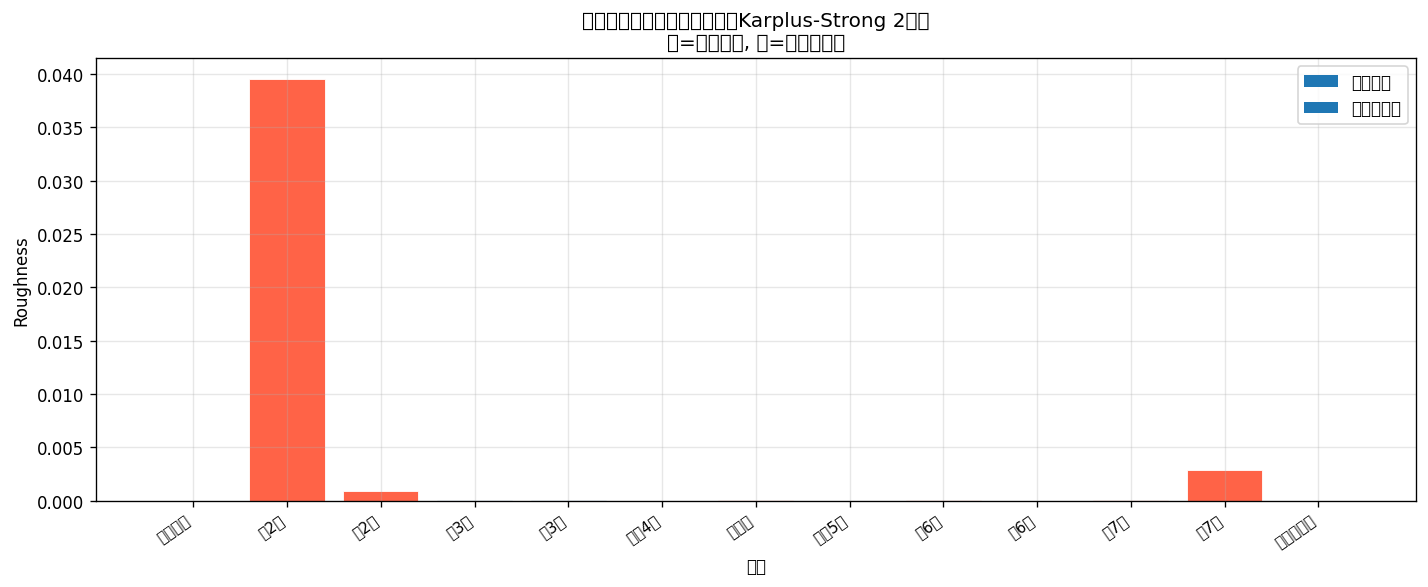


音程 → ラフネス（低い順）:
  オクターブ       : 0.0000
  ユニゾン        : 0.0000
  完全5度        : 0.0000
  長6度         : 0.0000
  完全4度        : 0.0000
  長3度         : 0.0000
  短7度         : 0.0000
  短6度         : 0.0001
  三全音         : 0.0001
  短3度         : 0.0001
  長2度         : 0.0009
  長7度         : 0.0029
  短2度         : 0.0395


In [4]:
def karplus_strong(freq, duration=1.0, sr=44100, decay=0.998):
    buf = np.random.default_rng(42).uniform(-1, 1, max(2, int(round(sr/freq))))
    n = int(sr * duration)
    out = np.empty(n)
    for i in range(n):
        idx = i % len(buf)
        out[i] = buf[idx]
        nxt = (idx + 1) % len(buf)
        buf[idx] = decay * 0.5 * (buf[idx] + buf[nxt])
    return out / (np.max(np.abs(out)) + 1e-9)


# 音程の定義（セント → 周波数比）
INTERVALS = {
    'ユニゾン':    0,
    '短2度':      100,
    '長2度':      200,
    '短3度':      300,
    '長3度':      400,
    '完全4度':    500,
    '三全音':     600,
    '完全5度':    700,
    '短6度':      800,
    '長6度':      900,
    '短7度':      1000,
    '長7度':      1100,
    'オクターブ': 1200,
}

f_root = 440.0
results = []

for name, cents in INTERVALS.items():
    f2 = f_root * 2 ** (cents / 1200)
    # 2音を足し合わせてスペクトル解析
    chord = karplus_strong(f_root) * 0.5 + karplus_strong(f2) * 0.5
    f_parts, a_parts = spectrum_to_partials(chord[:SR], SR, n_harmonics=20)
    r = roughness_sethares(f_parts, a_parts)
    results.append({'name': name, 'cents': cents, 'roughness': r, 'freq2': f2})

names_r    = [r['name'] for r in results]
roughness_r = [r['roughness'] for r in results]

# 協和音程を強調
consonant = {'ユニゾン', '完全4度', '完全5度', 'オクターブ', '長3度', '短3度'}
colors = ['steelblue' if n in consonant else 'tomato' for n in names_r]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(names_r, roughness_r, color=colors, edgecolor='white', linewidth=0.5)
ax.set_xlabel('音程')
ax.set_ylabel('Roughness')
ax.set_title('音楽的音程ごとのラフネス（Karplus-Strong 2音）\n青=協和音程, 赤=不協和音程')
plt.xticks(rotation=35, ha='right', fontsize=9)

# 協和・不協和の凡例
ax.bar([], [], color='steelblue', label='協和音程')
ax.bar([], [], color='tomato', label='不協和音程')
ax.legend()

plt.tight_layout()
plt.savefig(DATA_DIR / 'interval_roughness.png', bbox_inches='tight')
plt.show()

print('\n音程 → ラフネス（低い順）:')
for r in sorted(results, key=lambda x: x['roughness']):
    print(f"  {r['name']:12s}: {r['roughness']:.4f}")

---
## 4. FM 合成の C:M 比とラフネス

FM 合成では Carrier（C）と Modulator（M）の周波数比 C:M が音色を決定する。  
C:M が整数比のとき倍音が整列し（調和的）、そうでないときに非調和な倍音が生まれてラフネスが高くなる。

/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_88971/3227198940.py:36: UserWarning: Glyph 27604 (\N{CJK UNIFIED IDEOGRAPH-6BD4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_88971/3227198940.py:36: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_88971/3227198940.py:36: UserWarning: Glyph 21608 (\N{CJK UNIFIED IDEOGRAPH-5468}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_88971/3227198940.py:36: UserWarning: Glyph 27874 (\N{CJK UNIFIED IDEOGRAPH-6CE2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_88971/3227198940.py:36: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkk

/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_88971/3227198940.py:36: UserWarning: Glyph 38738 (\N{CJK UNIFIED IDEOGRAPH-9752}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_88971/3227198940.py:36: UserWarning: Glyph 32294 (\N{CJK UNIFIED IDEOGRAPH-7E26}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_88971/3227198940.py:36: UserWarning: Glyph 32218 (\N{CJK UNIFIED IDEOGRAPH-7DDA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_88971/3227198940.py:36: UserWarning: Glyph 25972 (\N{CJK UNIFIED IDEOGRAPH-6574}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_88971/3227198940.py:36: UserWarning: Glyph 38899 (\N{CJK UNIFIED IDEOGRAPH-97F3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkk

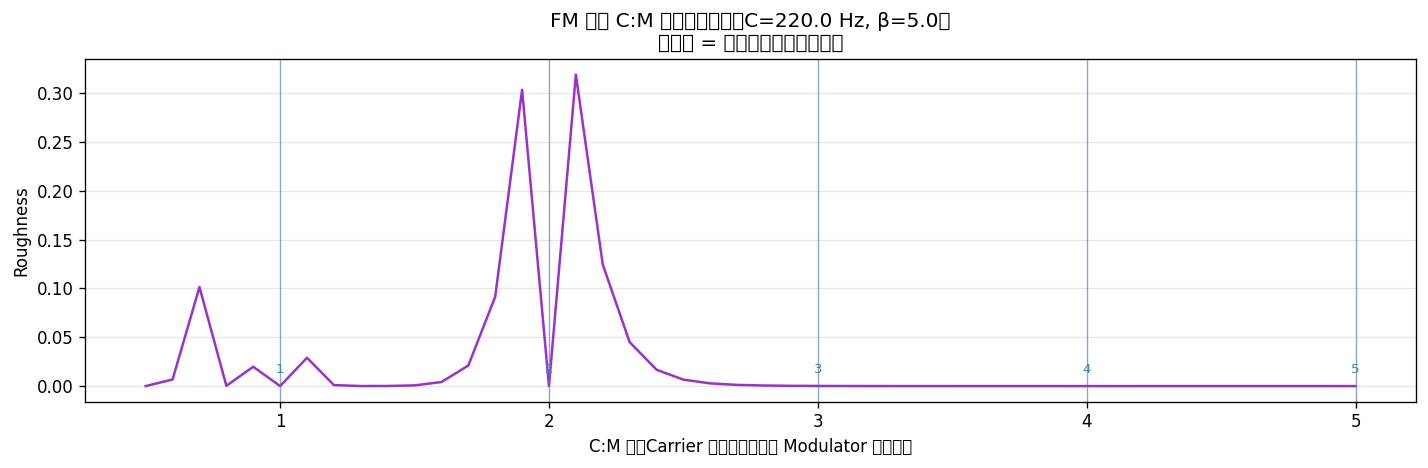

整数比付近でラフネスが谷（局所最小）になる = 調和的な音色
非整数比でラフネスが山 = 金属的・打楽器的な音色


In [5]:
def fm_synth(fc, cm_ratio, beta, duration=1.0, sr=44100):
    """簡単な FM 合成音（C:M = 1:cm_ratio）"""
    fm = fc * cm_ratio
    t  = np.arange(int(sr * duration)) / sr
    env = np.exp(-3 * t)   # 簡易エンベロープ
    return env * np.sin(2*np.pi*fc*t + beta * np.sin(2*np.pi*fm*t))


FC   = 220.0
BETA = 5.0
# 整数比・非整数比を含む C:M 範囲
cm_ratios = np.round(np.arange(0.5, 5.01, 0.1), 2)

fm_roughness = []
for cm in cm_ratios:
    sig = fm_synth(FC, cm, BETA, duration=0.5, sr=SR)
    f_p, a_p = spectrum_to_partials(sig, SR, n_harmonics=24)
    fm_roughness.append(roughness_sethares(f_p, a_p))

fm_roughness = np.array(fm_roughness)

# 整数比の位置をマーク
int_ratios = [r for r in cm_ratios if abs(r - round(r)) < 0.05]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(cm_ratios, fm_roughness, color='darkorchid', linewidth=1.5)
for ir in int_ratios:
    idx = np.argmin(np.abs(cm_ratios - ir))
    ax.axvline(ir, color='steelblue', linewidth=0.8, alpha=0.6)
    ax.annotate(f'{ir:.0f}', xy=(ir, fm_roughness[idx]),
                xytext=(0, 8), textcoords='offset points',
                ha='center', fontsize=8, color='steelblue')
ax.set_xlabel('C:M 比（Carrier 周波数に対する Modulator の倍率）')
ax.set_ylabel('Roughness')
ax.set_title(f'FM 合成 C:M 比とラフネス（C={FC} Hz, β={BETA}）\n青縦線 = 整数比（倍音が整列）')
plt.tight_layout()
plt.savefig(DATA_DIR / 'fm_roughness.png', bbox_inches='tight')
plt.show()

print('整数比付近でラフネスが谷（局所最小）になる = 調和的な音色')
print('非整数比でラフネスが山 = 金属的・打楽器的な音色')

---
## まとめ

| 確認できたこと | 詳細 |
|---|---|
| ラフネス曲線 | 差音 30〜80 Hz 付近で最大。それ以上離れると減少する |
| 音程と協和性 | 完全5度・完全4度・オクターブが低ラフネス。三全音・短2度が高ラフネス |
| FM 合成 | C:M が整数比（1:1, 1:2...）のとき倍音が整列して低ラフネス = 調和的音色 |
| 応用 | C:M 比をずらすと「汚さ」「金属感」を意図的にコントロールできる |

### 次に試すこと

- `BETA`（変調深度）を変えてラフネスがどう変化するか調べる
- 3音コード（メジャー・マイナー等）のラフネスを比較する
- ラフネスを目標値としてシンセパラメータを自動最適化する